### 1. Import Libraries & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, chi2_contingency, f_oneway

sns.set_style("whitegrid")

df = pd.read_csv('../data/insurance.csv')
df.head()

Matplotlib is building the font cache; this may take a moment.


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### 2. Descriptive Metrics

- Calculating central tendency, dispersion, skewness, and kurtosis for all numerical features
(`age`, `bmi`, `children`, `charges`).

In [6]:
numerical_cols = ['age', 'bmi', 'children', 'charges']

desc_stats = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Std Dev': df[numerical_cols].std(),
    'IQR': df[numerical_cols].quantile(0.75) - df[numerical_cols].quantile(0.25),
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurt()
})

desc_stats

,Mean,Median,Std Dev,IQR,Skewness,Kurtosis
age,39.207025,39.000,14.049960,24.000000,0.055673,-1.245088
bmi,30.663397,30.400,6.098187,8.397500,0.284047,-0.050732
children,1.094918,1.000,1.205493,2.000000,0.938380,0.202454
charges,13270.422265,9382.033,12110.011237,11899.625365,1.515880,1.606299


- Age is mostly symmetrical as mean and median are very near and skewness is between -1 to 1, kurtosis <3 indicates fewer extreme values
- bmi is slightly skewed with mean>meadian and skewness>0 showing long tails toward right
- charges contains heavy tails to the right that is indicated by mean>median and also skewness > 1

### 3. Visual Exploration
- 3.1 Distribution Plots (Histograms + KDE)

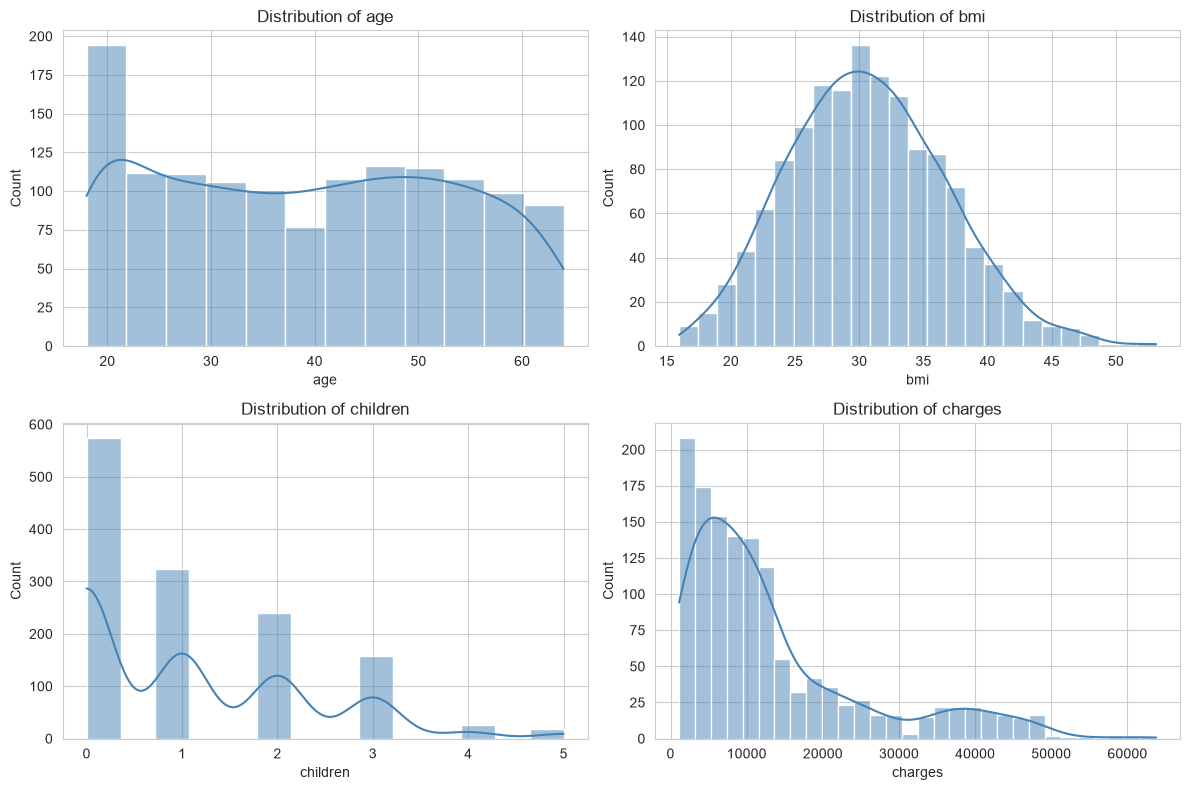

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

- 3.2 Bivariate Scatter Plots

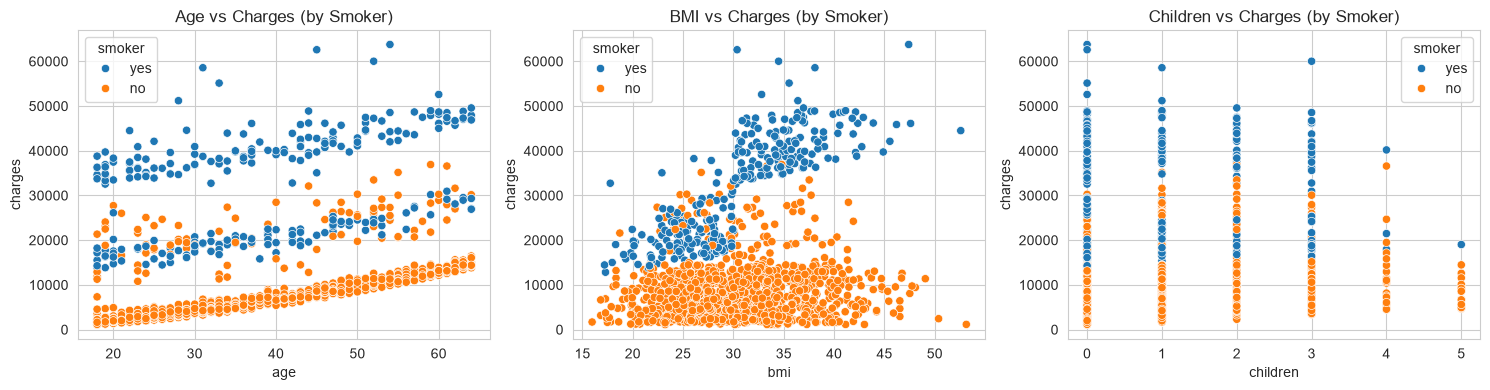

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', ax=axes[0])
axes[0].set_title('Age vs Charges (by Smoker)')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', ax=axes[1])
axes[1].set_title('BMI vs Charges (by Smoker)')

sns.scatterplot(data=df, x='children', y='charges', hue='smoker', ax=axes[2])
axes[2].set_title('Children vs Charges (by Smoker)')

plt.tight_layout()
plt.show()

- 3.3 Correlation Matrix

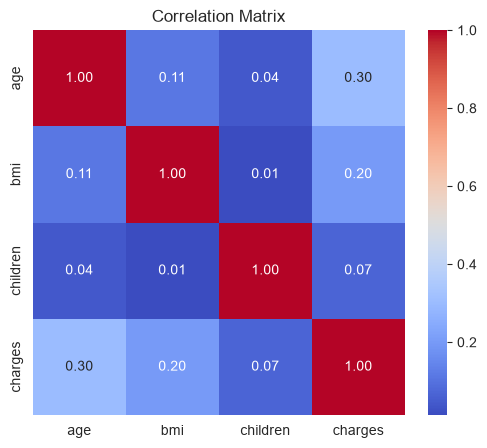

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

-  `age` and `bmi` show weak-to-moderate positive correlation with `charges`
- Note that `smoker` (categorical) is likely the strongest driver of `charges`, visible in the scatter plots even though it's not in the numeric correlation matrix

### 4. Hypothesis Test 1: Smokers vs. Non-Smokers — Medical Charges

**Hypotheses:**
- H0: There is no significant difference in mean medical charges between smokers and non-smokers.
- H1: There is a significant difference in mean medical charges between smokers and non-smokers.

**Significance level:** α = 0.05

**Steps:**
1. Check normality of `charges` within each group using the Shapiro-Wilk test.
2. Check equality of variances using Levene's test.
3. Based on the results, run either a Two-Sample t-test (if normal) or a Mann-Whitney U test (if not normal).
4. Draw a conclusion.

In [10]:
smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

# Step 1: Normality check
stat_smoker, p_smoker = shapiro(smokers)
stat_nonsmoker, p_nonsmoker = shapiro(non_smokers)

print(f"Shapiro-Wilk (Smokers): stat={stat_smoker:.4f}, p={p_smoker:.4g}")
print(f"Shapiro-Wilk (Non-Smokers): stat={stat_nonsmoker:.4f}, p={p_nonsmoker:.4g}")

Shapiro-Wilk (Smokers): stat=0.9396, p=3.625e-09
Shapiro-Wilk (Non-Smokers): stat=0.8729, p=1.446e-28


In [11]:
# Step 2: Equal variance check
stat_levene, p_levene = levene(smokers, non_smokers)
print(f"Levene's Test: stat={stat_levene:.4f}, p={p_levene:.4g}")

Levene's Test: stat=332.6135, p=1.559e-66


**Decision rule:**
- If both p-values from Shapiro-Wilk are > 0.05 → data is approximately normal → use t-test.
- If either p-value is ≤ 0.05 → data is not normal → use Mann-Whitney U test.
- Use the Levene's test result to decide `equal_var=True/False` if running a t-test.

In [12]:
alpha = 0.05

if p_smoker > alpha and p_nonsmoker > alpha:
    # Data is normal -> run t-test
    equal_var = p_levene > alpha
    stat, p_value = ttest_ind(smokers, non_smokers, equal_var=equal_var)
    test_used = "Two-Sample t-test"
else:
    # Data is not normal -> run Mann-Whitney U test
    stat, p_value = mannwhitneyu(smokers, non_smokers, alternative='two-sided')
    test_used = "Mann-Whitney U test"

print(f"Test used: {test_used}")
print(f"Statistic: {stat:.4f}, p-value: {p_value:.4g}")

if p_value < alpha:
    print("Conclusion: Reject H0 — there IS a significant difference in charges between smokers and non-smokers.")
else:
    print("Conclusion: Fail to Reject H0 — no significant difference detected.")

Test used: Mann-Whitney U test
Statistic: 284133.0000, p-value: 5.27e-130
Conclusion: Reject H0 — there IS a significant difference in charges between smokers and non-smokers.


**Final Conclusion (write after running):**
- Mann-Whitney U test was used as both the values are <0.05 , the p-value is 5.27e-130 , H0 was rejected
- Indicating that there is a difference in medical charges for smokers and non-smokers

### 5. Hypothesis Test 2 (Option B): One-Way ANOVA — Charges Across Regions

**Hypotheses:**
- H0: The mean medical charges are equal across all four regions.
- H1: At least one region has a significantly different mean charge.

**Significance level:** α = 0.05

In [13]:
regions = df['region'].unique()
region_groups = [df[df['region'] == r]['charges'] for r in regions]

stat_anova, p_anova = f_oneway(*region_groups)

print(f"Regions: {regions}")
print(f"F-statistic: {stat_anova:.4f}, p-value: {p_anova:.4g}")

if p_anova < alpha:
    print("Conclusion: Reject H0 — average charges differ significantly across regions.")
else:
    print("Conclusion: Fail to Reject H0 — no significant difference in average charges across regions.")

Regions: <ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
F-statistic: 2.9696, p-value: 0.03089
Conclusion: Reject H0 — average charges differ significantly across regions.


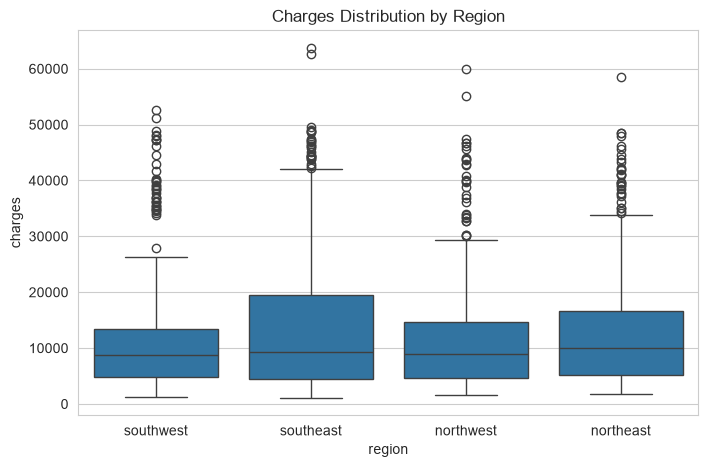

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='region', y='charges')
plt.title('Charges Distribution by Region')
plt.show()